# Experiment 3 (MRPC) — Factorized Embeddings 

Companion to the main Experiment 3 notebook. Reproduces the factorized-embedding comparison on MRPC (a sentence-pair paraphrase task, scored with accuracy and F1).

In [9]:
import os, sys

os.environ["USE_TF"] = "0"
os.environ["USE_TORCH"] = "1"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"

os.chdir(os.path.expanduser("~/DLNLP-ALBERT"))

SRC = os.path.abspath("src")
if SRC not in sys.path:
    sys.path.insert(0, SRC)

print("In:", os.getcwd())
print("CUDA available:", __import__("torch").cuda.is_available())

In: /home/jovyan/DLNLP-ALBERT
CUDA available: True


In [10]:
print(open("src/albert_project/training.py").read())

from __future__ import annotations

import os
import time
from pathlib import Path
from typing import Any

import numpy as np
import torch
from sklearn.metrics import accuracy_score, f1_score
from transformers import DataCollatorWithPadding, Trainer, TrainingArguments

from .data import get_task_spec, load_glue_task, select_train_fraction, tokenize_dataset
from .modeling import count_embedding_parameters, count_parameters, load_model_and_tokenizer


def compute_metrics_for_task(task_name: str):
    spec = get_task_spec(task_name)

    def compute(eval_pred: Any) -> dict[str, float]:
        logits, labels = eval_pred
        predictions = np.argmax(logits, axis=-1)
        result = {"accuracy": float(accuracy_score(labels, predictions))}
        if "f1" in spec.metric_names:
            result["f1"] = float(f1_score(labels, predictions))
        return result

    return compute


def _build_training_args(
    output_dir: str,
    epochs: float,
    batch_size: int,
    learning_rate: 

In [11]:
# %pip install "accelerate>=0.26.0"


## 1. Setup and training

Standard (E=768) vs factorized (E=128) embeddings, fine-tuned on MRPC for 3 epochs. Configs are identical except for `embedding_size`.

In [12]:
# %run experiments/factorized_embeddings/run_factorized_embeddings.py --train --config configs/factorized_embeddings/standard_embeddings_mrpc.yaml --config configs/factorized_embeddings/factorized_embeddings_mrpc.yaml

In [13]:
import os, sys

os.environ["USE_TF"] = "0"
os.environ["USE_TORCH"] = "1"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"

os.chdir(os.path.expanduser("~/DLNLP-ALBERT"))

SRC = os.path.abspath("src")
if SRC not in sys.path:
    sys.path.insert(0, SRC)

import torch
print("In:", os.getcwd())
print("CUDA available:", torch.cuda.is_available())

In: /home/jovyan/DLNLP-ALBERT
CUDA available: True


In [14]:
import os, pandas as pd
results = pd.read_csv(os.path.expanduser("~/DLNLP-ALBERT/results/embedding_results.csv"))
results[results["task_name"] == "mrpc"]

,experiment_name,configuration,model_label,model_name,model_source,task_name,parameters,embedding_parameters,notes,train_fraction,...,validation_examples,training_time_seconds,gpu_memory_mb,loss,accuracy,runtime,samples_per_second,steps_per_second,epoch,f1
12,factorized_embeddings,standard_embeddings_mrpc,ALBERT-standard-embeddings-mrpc,from_config,from_config,mrpc,31706882,23436288,Randomly initialized controlled architecture; ...,1.0,...,408.0,264.773,2496.900,0.609219,0.678922,3.4871,117.002,7.456,3.0,0.801214
13,factorized_embeddings,factorized_embeddings_mrpc,ALBERT-factorized-embeddings-mrpc,from_config,from_config,mrpc,11685122,3906048,Randomly initialized controlled architecture; ...,1.0,...,408.0,263.204,2259.598,0.620739,0.683824,3.4575,118.003,7.520,3.0,0.812227


## 2. Results ( MRPC vs SST2 )

MRPC reports both accuracy and F1. As with SST-2, factorization cuts parameters about 6× on embeddings (about 63% total). 

In [15]:
import os, pandas as pd

results = pd.read_csv(os.path.expanduser("~/DLNLP-ALBERT/results/embedding_results.csv"))

# keep only trained runs, one row per configuration
trained = results[results["train_fraction"] == 1.0].drop_duplicates(subset=["configuration"], keep="last")

# show the columns that matter for the comparison
cols = ["task_name", "configuration", "parameters", "embedding_parameters", "accuracy", "f1"]  
trained[cols].sort_values(["task_name", "configuration"]).reset_index(drop=True)

,task_name,configuration,parameters,embedding_parameters,accuracy,f1
0,mrpc,factorized_embeddings_mrpc,11685122,3906048,0.683824,0.812227
1,mrpc,standard_embeddings_mrpc,31706882,23436288,0.678922,0.801214
2,sst2,factorized_embeddings,11685122,3906048,0.813073,NaN
3,sst2,standard_embeddings,31706882,23436288,0.824541,NaN


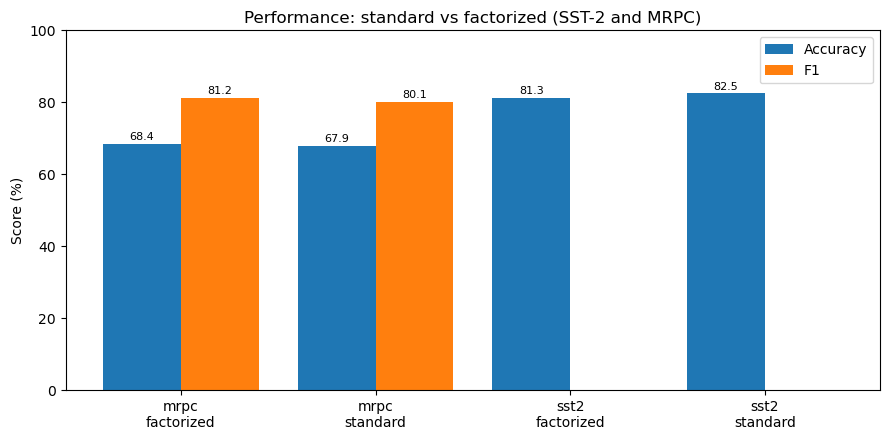

In [16]:
import os, pandas as pd, matplotlib.pyplot as plt, numpy as np

results = pd.read_csv(os.path.expanduser("~/DLNLP-ALBERT/results/embedding_results.csv"))
trained = results[results["train_fraction"] == 1.0].drop_duplicates(subset=["configuration"], keep="last")

# build labels like "sst2 / standard"
trained = trained.sort_values(["task_name", "configuration"])
labels = [f"{t}\n{c.replace('_mrpc','').replace('_embeddings','')}"
          for t, c in zip(trained["task_name"], trained["configuration"])]

x = np.arange(len(labels))
acc = trained["accuracy"].values * 100
f1  = trained["f1"].fillna(0).values * 100   # SST-2 has no F1

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x - 0.2, acc, width=0.4, label="Accuracy")
ax.bar(x + 0.2, f1,  width=0.4, label="F1")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("Score (%)")
ax.set_ylim(0, 100)
ax.set_title("Performance: standard vs factorized (SST-2 and MRPC)")
ax.legend()
for i, (a, f) in enumerate(zip(acc, f1)):
    ax.text(i - 0.2, a + 1, f"{a:.1f}", ha="center", fontsize=8)
    if f > 0:
        ax.text(i + 0.2, f + 1, f"{f:.1f}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

## 3. Conclusion

Factorization again reduces parameters dramatically. However, both models converge to about 68% accuracy / 81% F1 — the majority-class baseline for MRPC (about 68% of pairs are paraphrases). This is expected: randomly-initialized models cannot learn paraphrase detection from MRPC's small training set (about 3,700 pairs) in 3 epochs. Crucially, standard and factorized behave identically, so the parameter-reduction comparison remains valid even though absolute accuracy is not meaningful learning. SST-2 (much larger) shows real learning and is the stronger performance demonstration.